# Video-Language Dataset Exploratory Data Analysis (EDA)
## MSR-VTT and MSVD Analysis

This notebook performs a deep exploratory data analysis on the MSR-VTT and MSVD datasets, focusing on linguistic diversity, video metadata, and multimodal alignment using CLIP.

### 1. Setup and Environment
Install strict dependencies for video decoding and NLP.

In [16]:
!pip install decord transformers spacy nltk scikit-image pandas matplotlib seaborn tqdm requests
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 35.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [17]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
import spacy
import nltk
from nltk.corpus import stopwords
from decord import VideoReader, cpu
from skimage.metrics import structural_similarity as ssim
from transformers import CLIPProcessor, CLIPModel
import torch
from google.colab import drive

nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
try:
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/Shareddrives/DATA 298A/DATA'
except:
    BASE_DIR = '.'

MSRVTT_DIR = os.path.join(BASE_DIR, 'MSRVTT')
MSVD_DIR = os.path.join(BASE_DIR, 'MSVD')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Data Loading & Normalization
Loading JSON metadata and flattening it into a unified DataFrame.

In [18]:
def load_msrvtt_data(dir_path):
    files = glob.glob(os.path.join(dir_path, "msrvtt_*.json"))
    data = []
    for f in files:
        with open(f, 'r') as j:
            content = json.load(j)

            # Extract category mapping if available
            cat_map = {}
            if 'videos' in content:
                for v in content['videos']:
                    cat_map[v['video_id']] = v.get('category', 'unknown')

            if 'sentences' in content:
                for s in content['sentences']:
                    vid = s['video_id']
                    data.append({
                        'video_id': vid,
                        'caption': s['caption'],
                        'source': 'MSR-VTT',
                        'category': cat_map.get(vid, 'unknown')
                    })
            else:
                for item in filter(lambda x: isinstance(x, dict), content):
                    vid = item.get('video_id')
                    data.append({
                        'video_id': vid,
                        'caption': item.get('caption'),
                        'source': 'MSR-VTT',
                        'category': 'unknown'
                    })
    return pd.DataFrame(data)

def load_msvd_data(dir_path):
    files = glob.glob(os.path.join(dir_path, "msvd_*.json"))
    data = []
    for f in files:
        with open(f, 'r') as j:
            content = json.load(j)
            for item in filter(lambda x: isinstance(x, dict), content):
                vid = item.get('video_id')
                caps = item.get('caption', [])
                if isinstance(caps, list):
                    for c in caps:
                        data.append({'video_id': vid, 'caption': c, 'source': 'MSVD', 'category': 'N/A'})
                else:
                    data.append({'video_id': vid, 'caption': caps, 'source': 'MSVD', 'category': 'N/A'})
    return pd.DataFrame(data)

df_vtt = load_msrvtt_data(MSRVTT_DIR)
df_msvd = load_msvd_data(MSVD_DIR)
df_all = pd.concat([df_vtt, df_msvd], ignore_index=True)

print(f"Total items loaded: {len(df_all)}")
df_all.head()

Total items loaded: 97837


,video_id,caption,source,category
0,video7020,a woman creating a fondant baby and flower,MSR-VTT,unknown
1,video7021,baseball player hits ball,MSR-VTT,unknown
2,video7024,little pet shop cat getting a bath and washed ...,MSR-VTT,unknown
3,video7025,a naked child runs through a field,MSR-VTT,unknown
4,video7026,a man is giving a review on a vehicle,MSR-VTT,unknown


### 3. Phase 1: Linguistic Analysis & Visualization
Examining word distributions, vocabulary frequency, and common nouns/verbs (actions vs. objects).

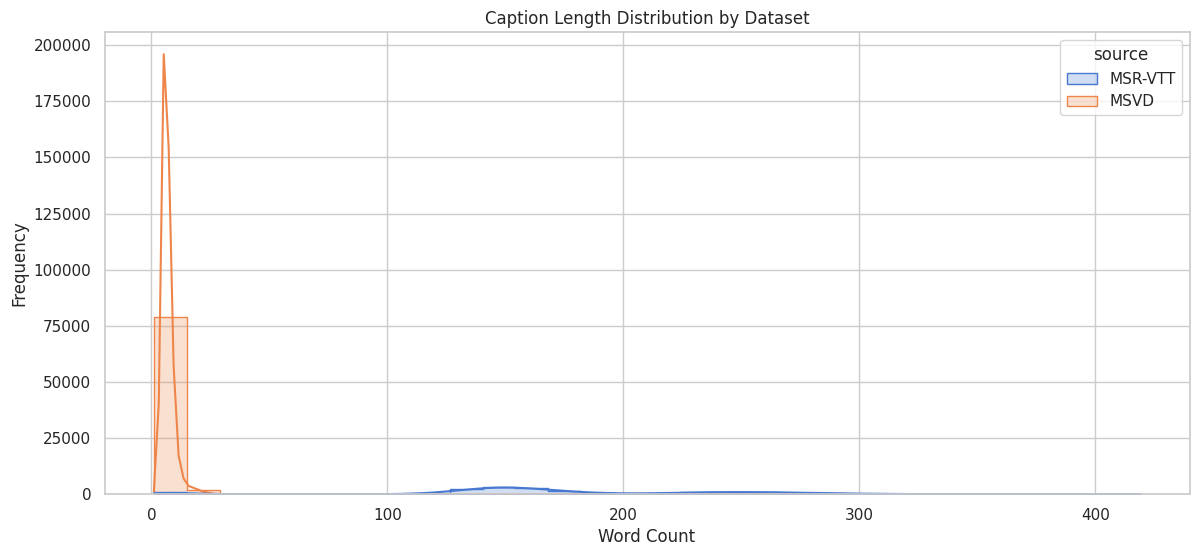

/tmp/ipykernel_7504/2615355261.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vocab, x='count', y='word', palette='viridis')


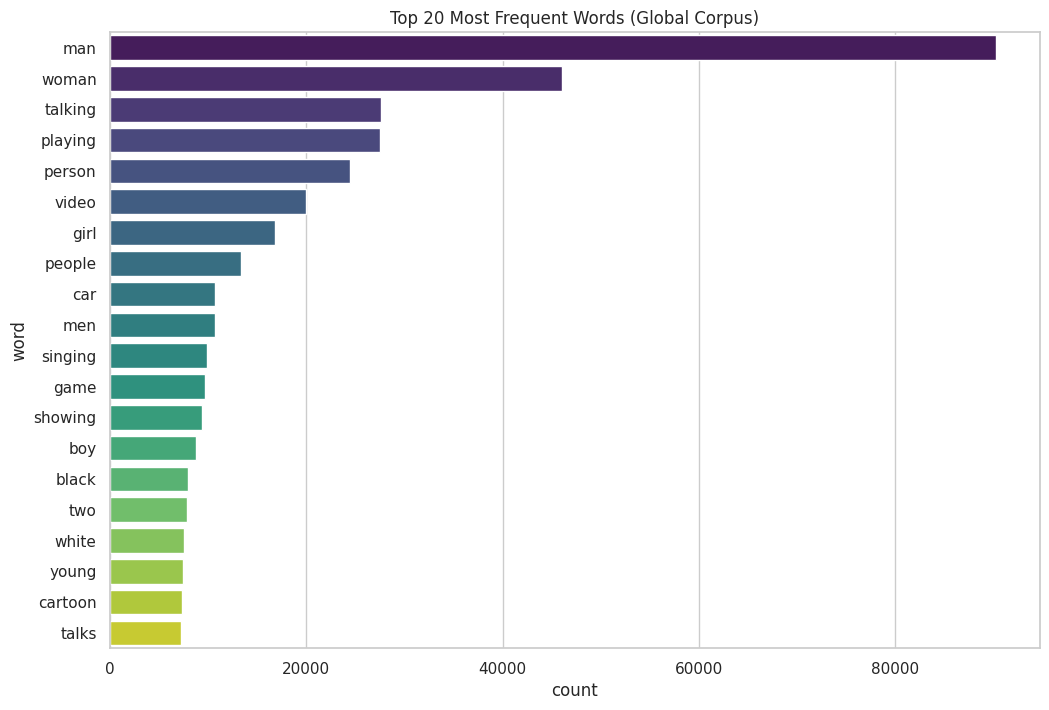

In [ ]:
# Caption Length Distribution
df_all['word_count'] = df_all['caption'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(14, 6))
sns.histplot(data=df_all, x='word_count', hue='source', kde=True, bins=30, element="step")
plt.title("Caption Length Distribution by Dataset")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# Vocabulary Overviews (Top 20 Frequent Words Excluding Stopwords)
all_caps = " ".join(df_all['caption'].astype(str).tolist()).lower().split()
clean_words = [w for w in all_caps if w.isalpha() and w not in stop_words]
word_counts = Counter(clean_words).most_common(20)
df_vocab = pd.DataFrame(word_counts, columns=['word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=df_vocab, x='count', y='word', palette='viridis')
plt.title("Top 20 Most Frequent Words (Global Corpus)")
plt.show()

Analyzing syntactic biases (nouns vs verbs)


/tmp/ipykernel_7504/3985466670.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c[1] for c in Counter(verbs).most_common(20)], y=[c[0] for c in Counter(verbs).most_common(20)], ax=axes[0], palette='magma')
/tmp/ipykernel_7504/3985466670.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c[1] for c in Counter(nouns).most_common(20)], y=[c[0] for c in Counter(nouns).most_common(20)], ax=axes[1], palette='flare')


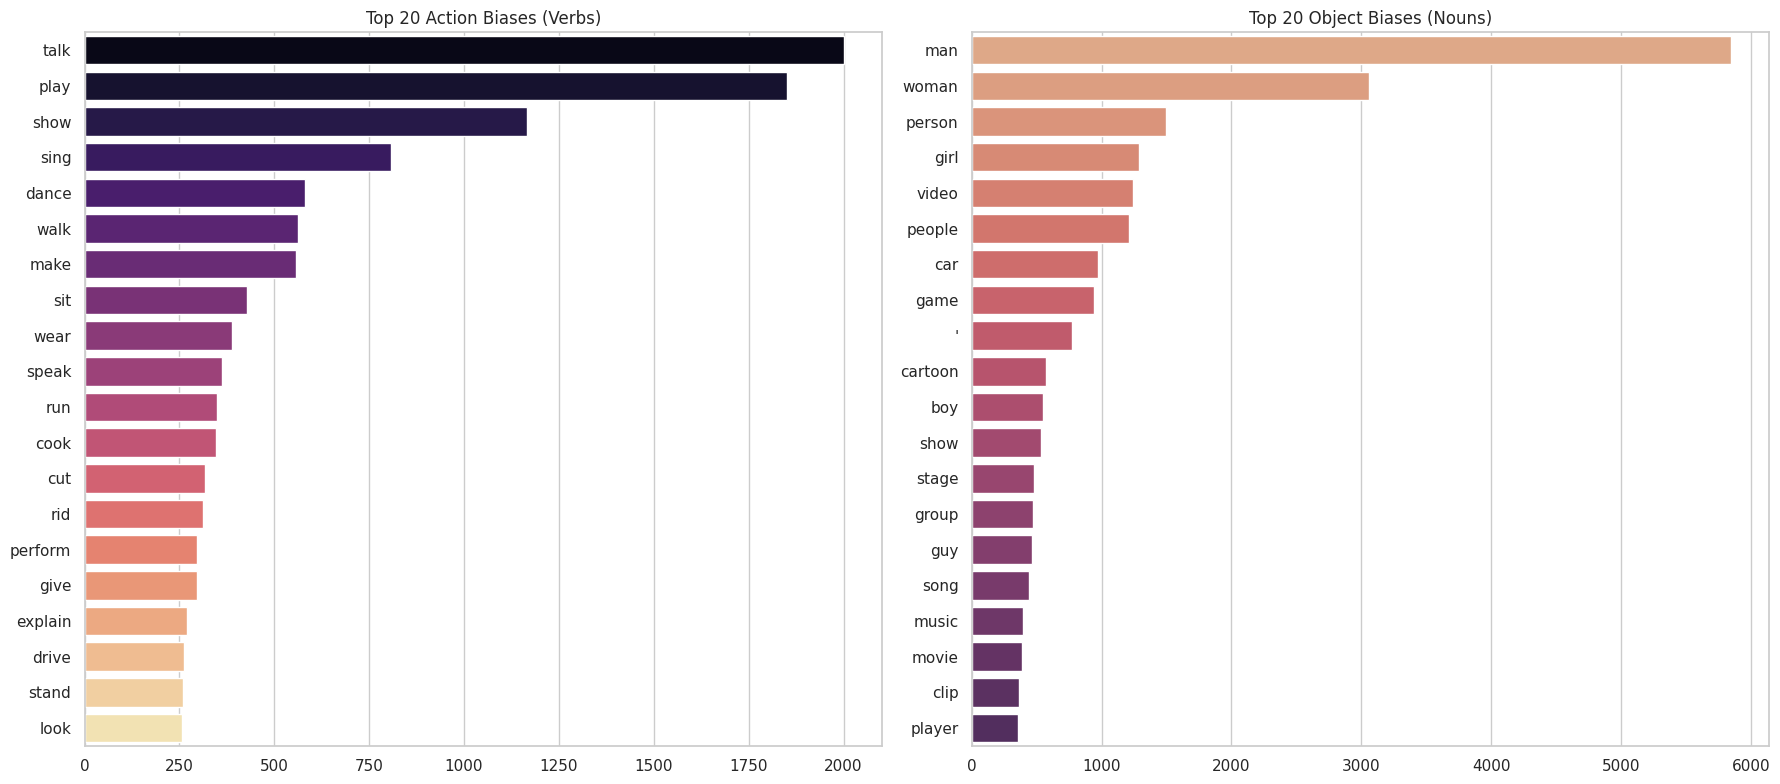

In [ ]:
# Syntactic Composition (POS Tagging)
print("Analyzing syntactic biases (nouns vs verbs)")
sample_text = " ".join(str(x) for x in df_all['caption'].sample(min(20000, len(df_all))).tolist())
doc = nlp(sample_text[:1000000])

verbs = [token.lemma_ for token in doc if token.pos_ == "VERB" and token.text.lower() not in stop_words]
nouns = [token.lemma_ for token in doc if token.pos_ == "NOUN" and token.text.lower() not in stop_words]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=[c[1] for c in Counter(verbs).most_common(20)], y=[c[0] for c in Counter(verbs).most_common(20)], ax=axes[0], palette='magma')
axes[0].set_title("Top 20 Action Biases (Verbs)")

sns.barplot(x=[c[1] for c in Counter(nouns).most_common(20)], y=[c[0] for c in Counter(nouns).most_common(20)], ax=axes[1], palette='flare')
axes[1].set_title("Top 20 Object Biases (Nouns)")

plt.tight_layout()
plt.show()

### 3.5. Detailed Dataset Metrics
Analyzing category balance, caption density per video, and redundancy level.

/tmp/ipykernel_7504/2058641826.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dupe_data, x='Metric', y='Count', palette='coolwarm') # Plot directly on the figure


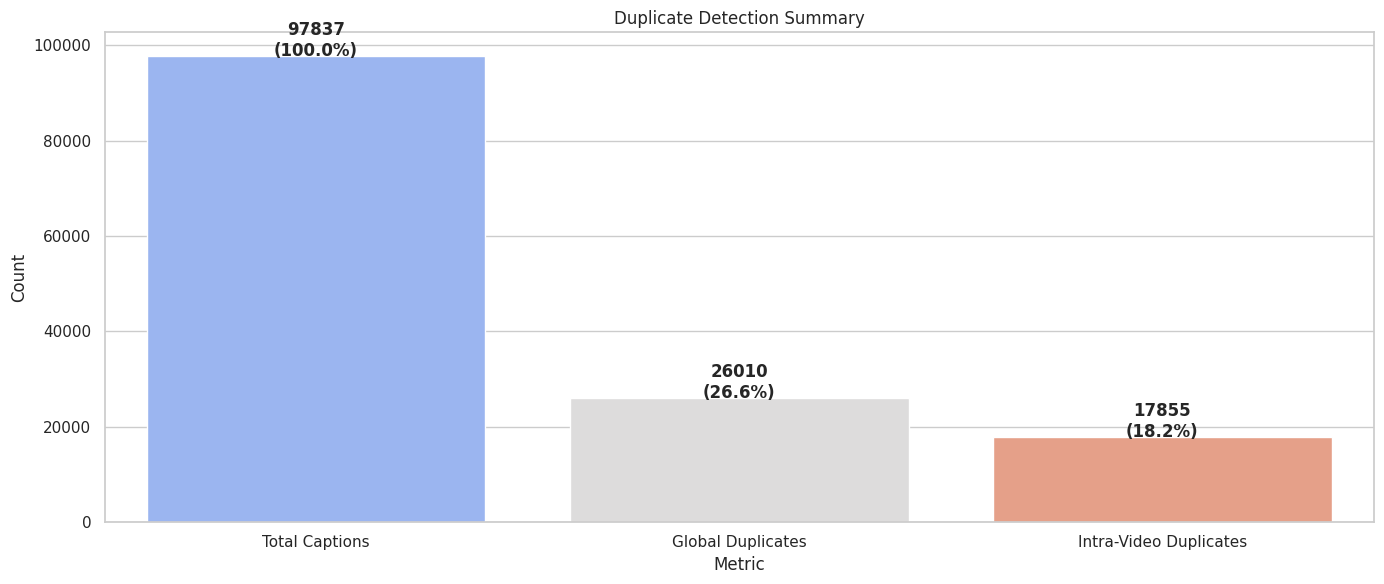

In [32]:
# Vocabulary Frequency, Duplicate Detection, Category Balance, and number of caption for each video

# Define variables for duplicate detection
total_caps = len(df_all)
global_dupes = df_all.duplicated(subset=['caption']).sum()
intra_video_dupes = df_all.duplicated(subset=['video_id', 'caption']).sum()

plt.figure(figsize=(14, 6)) # Create a single figure

dupe_data = pd.DataFrame({
    'Metric': ['Total Captions', 'Global Duplicates', 'Intra-Video Duplicates'],
    'Count': [total_caps, global_dupes, intra_video_dupes]
})
sns.barplot(data=dupe_data, x='Metric', y='Count', palette='coolwarm') # Plot directly on the figure
plt.title("Duplicate Detection Summary") # Set title for the single plot
for i, v in enumerate(dupe_data['Count']):
    plt.text(i, v + 10, f"{v}\n({v/total_caps:.1%})", ha='center', fontweight='bold') # Use plt.text for annotations


plt.tight_layout()
plt.show()

### 4. Phase 2: Visual & Structural Analysis
Extracting duration, resolution, and temporal dynamics (SSIM) to check for static vs. dynamic videos.

In [ ]:
def get_vpath(vid, src):
    if src == 'MSR-VTT':
        return os.path.join(MSRVTT_DIR, 'raw_videos', f"{vid}.mp4")
    return os.path.join(MSVD_DIR, 'raw_videos', f"{vid}.avi")

unique_vids = df_all[['video_id', 'source']].drop_duplicates().sample(min(200, len(df_all.video_id.unique()))) # Sample subset for fast metrics
video_metrics = []
print("Extracting structural metadata from video files...")

for _, row in tqdm(unique_vids.iterrows(), total=len(unique_vids)):
    p = get_vpath(row['video_id'], row['source'])
    if not os.path.exists(p): continue
    try:
        vr = VideoReader(p, ctx=cpu(0))
        fps = vr.get_avg_fps()
        frames = len(vr)
        cur_info = {
            'video_id': row['video_id'],
            'source': row['source'],
            'duration': frames / fps if fps > 0 else 0,
            'fps': fps,
            'res': f"{vr[0].shape[1]}x{vr[0].shape[0]}",
            'aspect': round(vr[0].shape[1] / vr[0].shape[0], 2)
        }
        # Temporal analysis (SSIM across 5 frames)
        indices = np.linspace(0, frames-1, 5, dtype=int)
        s_frames = vr.get_batch(indices).asnumpy()
        ssim_scores = [ssim(s_frames[i], s_frames[i+1], channel_axis=-1, data_range=255) for i in range(4)]
        cur_info['avg_ssim'] = np.mean(ssim_scores)
        video_metrics.append(cur_info)
    except:
        continue

df_vid = pd.DataFrame(video_metrics)

Extracting structural metadata from video files...


  0%|          | 0/200 [00:00<?, ?it/s]

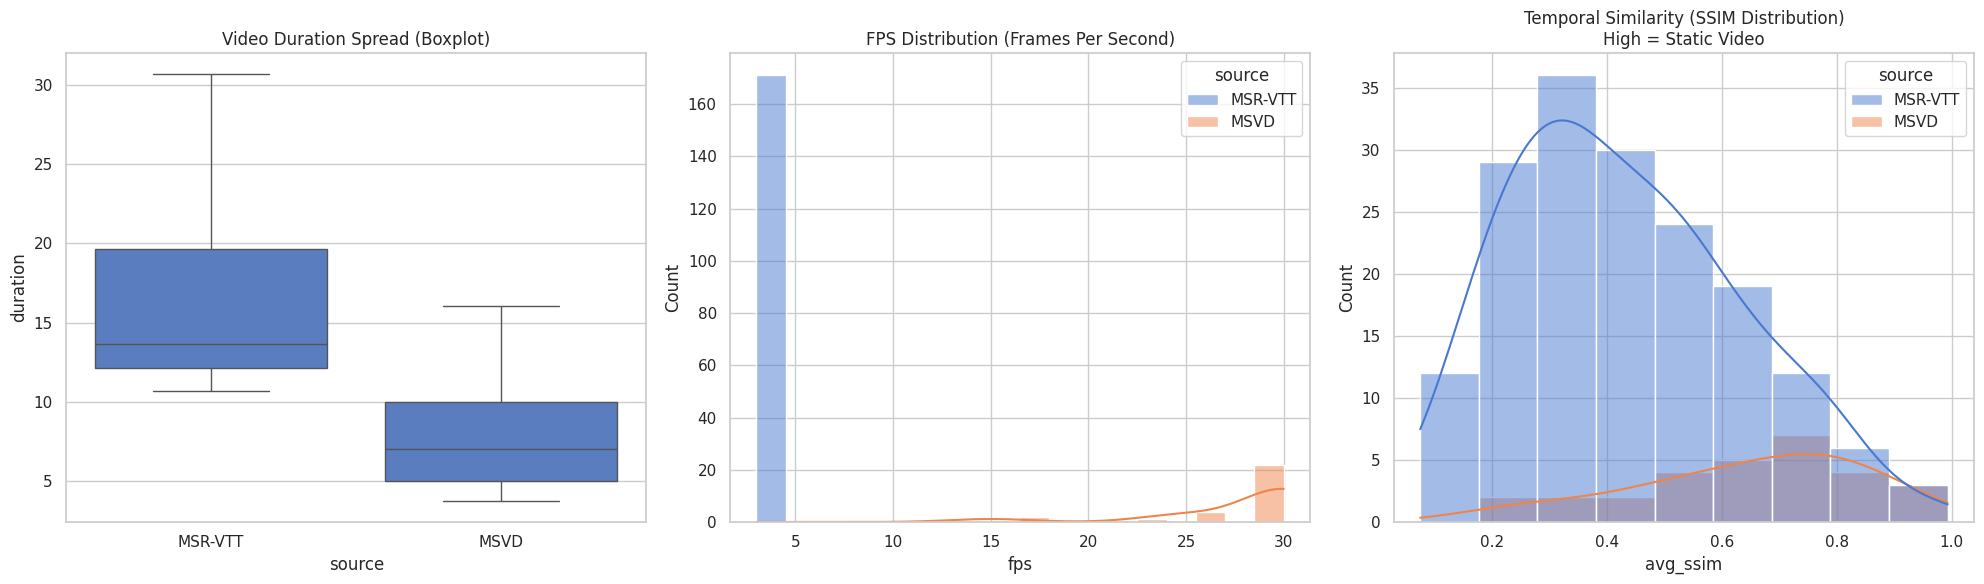

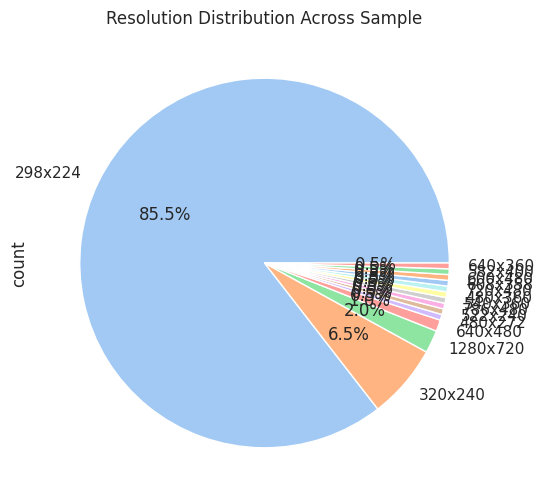

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df_vid, x='source', y='duration', ax=axes[0])
axes[0].set_title("Video Duration Spread (Boxplot)")

sns.histplot(data=df_vid, x='fps', hue='source', multiple="dodge", kde=True, ax=axes[1])
axes[1].set_title("FPS Distribution (Frames Per Second)")

sns.histplot(data=df_vid, x='avg_ssim', hue='source', kde=True, ax=axes[2])
axes[2].set_title("Temporal Similarity (SSIM Distribution)\nHigh = Static Video")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
df_vid['res'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Resolution Distribution Across Sample")
plt.show()

### 5. Phase 3: Multimodal Quality (CLIP Audit)
Calculating zero-shot similarity between video frames and captions to identify misaligned or low-quality pairs.

Initializing CLIP... loading ViT-B/32


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  0%|          | 0/100 [00:00<?, ?it/s]

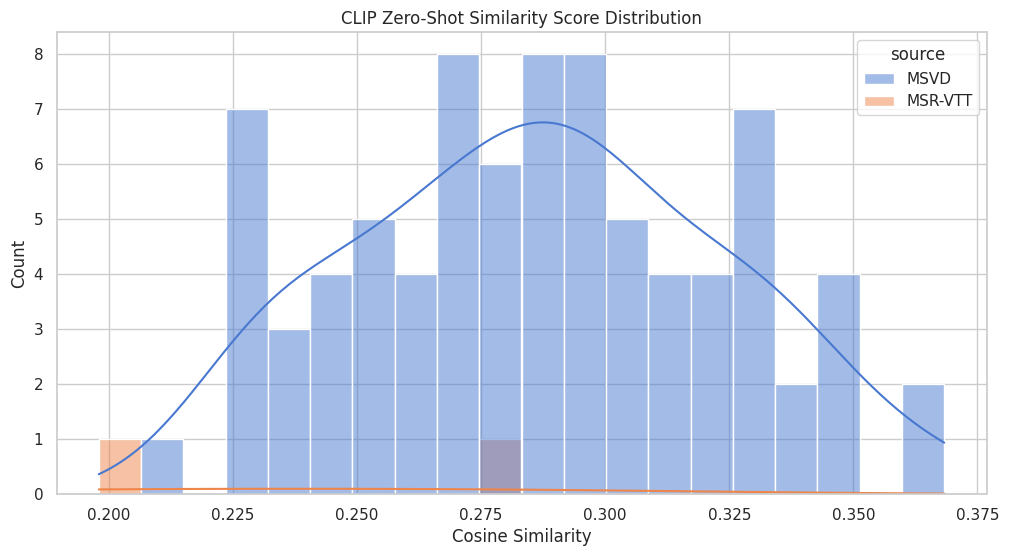

In [ ]:
print("Initializing CLIP... loading ViT-B/32")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def audit_clip(df_sample, n_samples=50):
    similarities = []
    samples = df_sample.sample(n_samples)
    for _, row in tqdm(samples.iterrows(), total=len(samples)):
        vpath = get_vpath(row['video_id'], row['source'])
        if not os.path.exists(vpath): continue
        try:
            vr = VideoReader(vpath, ctx=cpu(0))
            frame = vr[len(vr)//2].asnumpy()
            inputs = processor(text=[row['caption']], images=frame, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                # Calculating cosine similarity manually from logits isn't exactly direct,
                # we use the precomputed similarity from model pool if available or compute from embeddings.
                i_emb = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
                t_emb = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)
                sim = (i_emb * t_emb).sum().item()
                similarities.append({'video_id': row['video_id'], 'sim': sim, 'caption': row['caption'], 'source': row['source']})
        except:
            continue
    return pd.DataFrame(similarities)

df_sim = audit_clip(df_all, n_samples=100)

plt.figure(figsize=(12, 6))
sns.histplot(data=df_sim, x='sim', hue='source', kde=True, bins=20)
plt.title("CLIP Zero-Shot Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.show()

### 6. Outlier Visualization
Showing random samples of high-similarity vs low-similarity pairs to inspect quality visually.

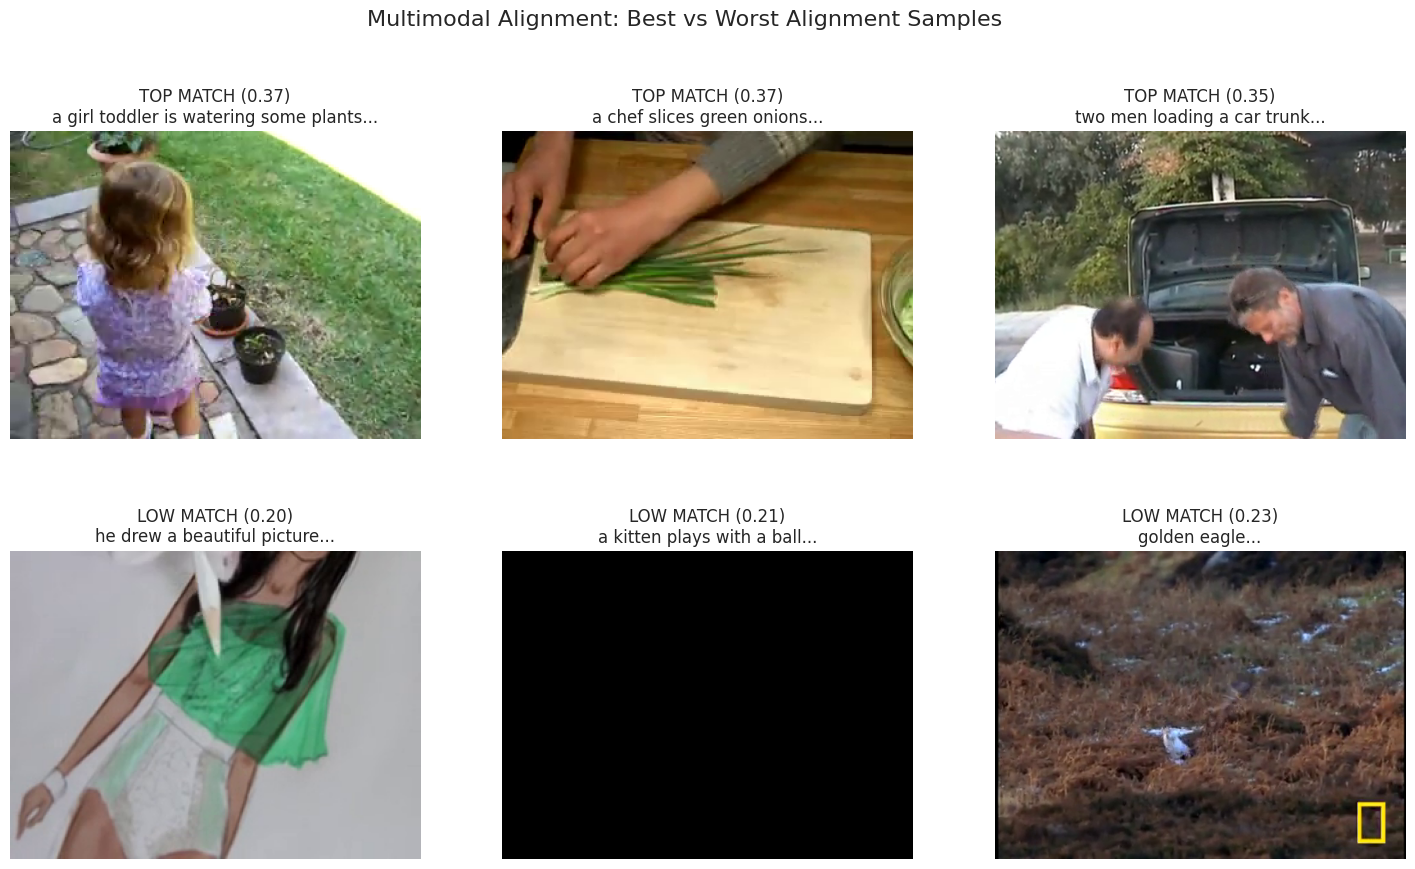

In [ ]:
def plot_samples(df_sim, n=3):
    top = df_sim.nlargest(n, 'sim')
    bot = df_sim.nsmallest(n, 'sim')

    fig, axes = plt.subplots(2, n, figsize=(18, 10))

    for i, (_, row) in enumerate(top.iterrows()):
        vr = VideoReader(get_vpath(row['video_id'], row['source']))
        axes[0, i].imshow(vr[len(vr)//2].asnumpy())
        axes[0, i].set_title(f"TOP MATCH ({row['sim']:.2f})\n{row['caption'][:40]}...")
        axes[0, i].axis('off')

    for i, (_, row) in enumerate(bot.iterrows()):
        vr = VideoReader(get_vpath(row['video_id'], row['source']))
        axes[1, i].imshow(vr[len(vr)//2].asnumpy())
        axes[1, i].set_title(f"LOW MATCH ({row['sim']:.2f})\n{row['caption'][:40]}...")
        axes[1, i].axis('off')

    plt.suptitle("Multimodal Alignment: Best vs Worst Alignment Samples", fontsize=16)
    plt.show()

plot_samples(df_sim)